
# Final Project - Realized Volatility Timing (Simple Version)

Objectif du projet:
1. Estimer une volatilité réalisée latente \(\hat\sigma_t\) avec un modèle d'état Heston + UKF.
2. Construire le spread \(s_t = \sigma_{IV,t} - \hat\sigma_t\).
3. Utiliser ce spread pour timer une stratégie carry déjà vue en cours.
4. Comparer baseline vs version timed.



## 1) Setup


In [1]:

%load_ext autoreload
%autoreload 2

from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from investment_lab.data.option_db import OptionLoader
from investment_lab.option_trade import OptionTrade
from investment_lab.backtest import StrategyBacktester, BacktesterBidAskFromData
from investment_lab import option_strategies
from investment_lab.option_selection import select_options
from investment_lab.metrics.performance import sharpe_ratio, max_drawdown, calmar_ratio

from investment_lab.signals.vol_timing import (
    VolTimingConfig,
    build_iv_rv_timing_signal,
    apply_timing_weight_to_positions,
)



## 2) Paramètres projet

Garde volontairement simple et proche du cours.


In [2]:

START = datetime(2020, 1, 6)
END = datetime(2022, 12, 4)
TICKER = "SPY"

# Stratégie carry baseline (vue en cours)
LEGS = option_strategies.SHORT_1W_STRANGLE_95_105

# Paramètres timing (simples)
signal_cfg = VolTimingConfig(
    rolling_window=126,  # ~6 mois
    min_obs=100,
    iv_col="implied_volatility",
    ret_col="log_return",
    base_weight=1.0,
    slope=2.0,
    min_weight=0.5,
    max_weight=1.5,
)



## 3) Construire les séries d'entrée du signal

- `log_return`: retour journalier du spot SPY
- `implied_volatility`: proxy IV daily (call ATM ~1M)


In [3]:

df_options = OptionLoader.load_data(START, END, process_kwargs={"ticker": TICKER})

# Spot quotidien
spot_daily = (
    df_options.groupby("date", as_index=False)["spot"]
    .first()
    .sort_values("date")
)
spot_daily["log_return"] = np.log(spot_daily["spot"]).diff()

# IV proxy: call proche ATM (moneyness=1), maturité proche 30j
iv_proxy = select_options(
    df_options,
    call_or_put="C",
    strike_col="moneyness",
    strike_target=1.0,
    day_to_expiry_target=30,
)[["date", "implied_volatility"]].drop_duplicates("date")

signal_input = (
    spot_daily[["date", "log_return"]]
    .merge(iv_proxy, on="date", how="inner")
    .dropna()
    .sort_values("date")
)

signal_input.head(), signal_input.tail()


FileNotFoundError: [Errno 2] No such file or directory: '../../..//data/optiondb_2016_2023.parquet'


## 4) Estimation UKF-Heston et signal de timing


In [4]:

df_signal = build_iv_rv_timing_signal(signal_input, config=signal_cfg)

df_signal[["date", "rv_hat", "spread", "timing_weight"]].tail()


,date,rv_hat,spread,timing_weight
731,2022-11-28,0.204634,-0.004064,0.991872
732,2022-11-29,0.229043,-0.021543,0.956913
733,2022-11-30,0.217715,-0.030215,0.939570
734,2022-12-01,0.205003,-0.017713,0.964574
735,2022-12-02,0.193259,-0.011539,0.976922


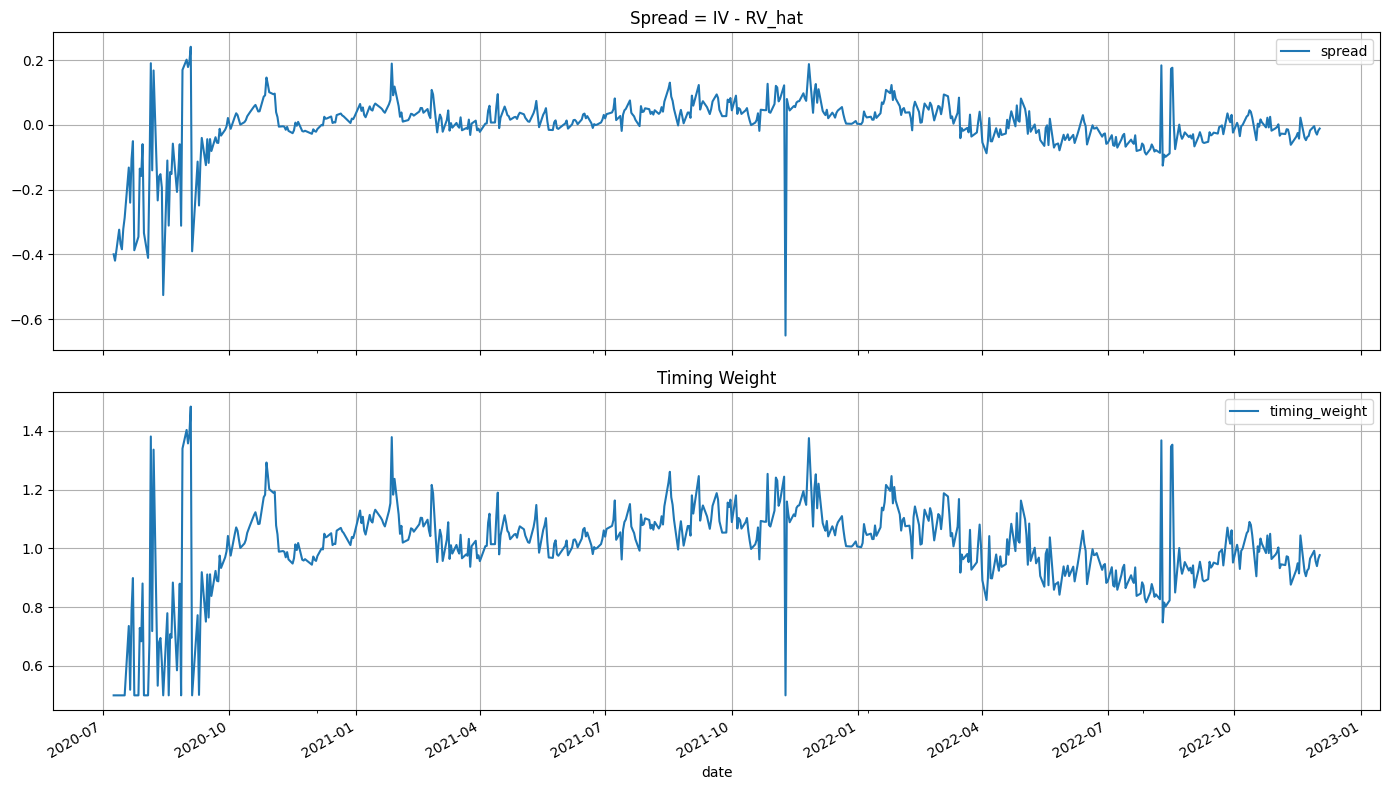

In [5]:

fig, ax = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

df_signal.set_index("date")[["spread"]].plot(ax=ax[0], grid=True, title="Spread = IV - RV_hat")
df_signal.set_index("date")[["timing_weight"]].plot(ax=ax[1], grid=True, title="Timing Weight")

plt.tight_layout()



## 5) Baseline stratégie carry


In [6]:

df_positions_baseline = OptionTrade.generate_trades(
    start_date=START,
    end_date=END,
    tickers=TICKER,
    legs=LEGS,
    cost_neutral=False,
)

bt_baseline = BacktesterBidAskFromData(df_positions_baseline).compute_backtest()
bt_baseline.nav.tail()


ValueError: df_options is missing columns: {'option_id'}


## 6) Version timed (allocation dynamique)


In [ ]:

df_positions_timed = apply_timing_weight_to_positions(df_positions_baseline, df_signal)

bt_timed = BacktesterBidAskFromData(df_positions_timed).compute_backtest()
bt_timed.nav.tail()



## 7) Comparaison des performances


In [ ]:

nav_compare = pd.concat(
    {
        "Baseline": bt_baseline.nav["NAV"],
        "Timed": bt_timed.nav["NAV"],
    },
    axis=1,
).dropna()

ax = nav_compare.plot(figsize=(14, 5), grid=True, title="NAV Comparison: Baseline vs Timed")
ax.set_ylabel("NAV")
plt.show()


In [ ]:

def perf_table(nav_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for col in nav_df.columns:
        rets = nav_df[col].pct_change().dropna()
        rows.append(
            {
                "strategy": col,
                "sharpe": sharpe_ratio(rets),
                "max_drawdown": max_drawdown(nav_df[col]),
                "calmar": calmar_ratio(rets),
                "final_nav": nav_df[col].iloc[-1],
            }
        )
    return pd.DataFrame(rows).set_index("strategy")

perf_table(nav_compare)



## 8) Conclusion courte (à compléter pour le rendu)

- Le signal UKF-Heston fournit une estimation \(\hat\sigma_t\) de la vol réalisée latente.
- Le spread IV-RV_hat sert à augmenter/réduire l'exposition au carry.
- On valide la valeur ajoutée avec la comparaison baseline vs timed (NAV + Sharpe + Drawdown).

### Extensions simples
- Tester `rolling_window` = 63 / 126 / 252
- Tester `slope` = 1 / 2 / 3
- Tester bornes de poids `[0.5,1.5]` vs `[0,2]`
